## 18 June 2026
## Sapkas Michail
### Lunar Lander - Final Project for Deep Neural Networks

Implement the
# Deep Recurrent Q-Learning Network (DRQN) algorithm
- using a Gated Recurrent Unit (GRU) architecture.

In [1]:
import torch
import random
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import time

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")  # For Mac Apple Silicon users
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


# Some notes on using the GRU
The RNN training was highly unstable, and as much as I wanted to not use raw compute, I eventually had to rely on offloading the Bayesian optimization of the following hyperparameters to one of our INFN servers in Padova. I experimented a lot with it manually at first and it is interesting to note that I started with "small" sequences of 8 to 16 steps and the model was epicaly failing to learn. Then, I randomly used a larger sequence of 32 to 64 and the model got much better. This is kinda counterintuitive, as one would expect that the model would be able to learn better with smaller sequences, but it seems that the model needs a larger context to learn effectively.

Here are my two best runs using Optuna. I'm going to use the same HPs of the second run:

- Trial 15 finished with value: 209.3706835198205 and parameters: 

    - 'learning_rate': 0.0009265068810450335
    - 'batch_size': 128
    - 'num_terminal_sequences': 25
    - 'gamma': 0.984279576609137
    - 'tau': 0.41469479617104366
    - 'train_freq': 20
    - 'epsilon_decay': 0.9932913817111452
    - 'burn_in_samples': 6
    - 'sequence_length': 92
    - 'latent_dimension': 293

- Trial 21 finished with value: 224.49027652901415 and parameters:

    - 'learning_rate': 0.001819643054540983
    - 'batch_size': 128
    - 'num_terminal_sequences': 14
    - 'gamma': 0.984498899382558
    - 'tau': 0.3270926070218232
    - 'train_freq': 20
    - 'epsilon_decay': 0.9936495656374817
    - 'burn_in_samples': 3
    - 'sequence_length': 79
    - 'latent_dimension': 324

Defining all the hyperparameters of the algorithm: 

- **LATENT_DIM** is the dimension of the first dense neural network embedding layer and the dimension of the hidden state of the GRU
- **BURN_IN_LENGTH** was a method used before using long sequences to "warm-up" the hidden state of the GRU before start accumulating gradients. I kept it, but may as well make no difference.
- **SEQUENCE_LENGTH** is the length of the sequences that are sampled from the replay buffer to train the network
- **BATCH_SIZE** is the number of samples randomly sampled from the replay buffer to train the network
- **LEARNING_RATE** is self explanatory. I am using adam
- **NUM_TERMINAL_SEQUENCES** is the number of terminal sequences (the ones that will end with a done=True) that are sampled from the replay buffer to train the network. The idea was to have the notion of a terminal state in the training, but I am not sure if it is really helping. I will keep it for now.
- **REPLAY_BUFFER_EPISODES** is the capacity of the replay buffer in episodic granularity.
- **MIN_REPLAY_EPISODES** is the warm-up episodes (full with random actions) that fill the replay buffer before training starts
- **GAMMA** is the discount factor for future rewards (in this context, because it is multiplying the estimated future rewards Q it can also represent the "trust" or "importance" of our estimation)
- **TAU** is the soft update parameter using the polyak method for updating the target network
- **TRAIN_FREQ** is the frequency of training the network in **steps**
- **TARGET_UPDATE_FREQ** is the frequency of updating the target network in **steps**
- **EPSILON_START** is the initial value of epsilon for the epsilon-greedy exploration strategy
- **EPSILON_DECAY** is the multiplicative factor by which epsilon is decayed after each episode
- **EPSILON_MIN** is the minimum value of epsilon for the epsilon-greedy exploration strategy
- **TOTAL_TIMESTEPS** is self explanatory. The total number of steps until the training is finished

In [ ]:
LATENT_DIM = 284
BURN_IN_LENGTH = 6
SEQUENCE_LENGTH = 92

BATCH_SIZE = 128
LEARNING_RATE = 0.0009265
NUM_TERMINAL_SEQUENCES = 25

REPLAY_BUFFER_EPISODES = 500
MIN_REPLAY_EPISODES = 250

GAMMA = 0.984
TAU = 0.415

TRAIN_FREQ = 20
TARGET_UPDATE_FREQ = 20

EPSILON_START = 1.0
EPSILON_DECAY = 0.993
EPSILON_MIN = 0.01

MAX_GRAD_NORM = 10.0

TOTAL_TIMESTEPS = 400_000

The neural network with a core RNN architecture:
- First an "embedding" layer that transforms the input state (8 vector) into a higher dimensional space (LATENT_DIM) that matches the hidden state of the GRU. This is a dense layer with ReLU activation.
- Then a GRU layer that takes the embedded state and the previous hidden state and outputs the new hidden state. Simpler and same efficiency with the LSTM.
- Finally a dense layer that takes the hidden state of the GRU and outputs the Q-values for each action (4 actions). This is a dense layer with no activation function.

In [3]:
class DRQNNetwork(nn.Module):
    def __init__(self, state_dim=8, action_dim=4, hidden_dim=LATENT_DIM):
        super().__init__()
        # Pre-process raw state features first
        self.feature_extractor = nn.Sequential(nn.Linear(state_dim, hidden_dim),nn.ELU())
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, action_dim)

    def forward(self, x, hidden_state=None):
        features = self.feature_extractor(x)
        gru_out, hidden_state = self.gru(features, hidden_state)
        q_values = self.fc_out(gru_out)
        return q_values, hidden_state

In [4]:
def update_epsilon_decay(epsilon):
    # Updated to check minimum episode constraints instead of individual step size
    if len(replay_buffer) < MIN_REPLAY_EPISODES:
        return epsilon
    return max(EPSILON_MIN, epsilon * EPSILON_DECAY)

This is probably the most important part of the code, as it will handle the proper preparation of the sequences to be fed to the GRU. There are a bunch of stuff going on here, but the most important part is that it works well with the idea to store whole episodes in the replay buffer and then sample sequences from them. Lets see what the code does:

- Define empty lists in which we will store the batches to train
- Compute the sample length given the hyperparameters of the algorithm. The final +1 sample is needed to compute the target Q-value for the last state of the sequence

- A **terminal_episodes** list is created to store the indices of the episodes that are terminal (done=True). This is needed to sample terminal sequences from the replay buffer. We will also need to compensate in case the sampled sequence is smaller than the requested sequence length, but this is done later.

- First sample terminal sequences from the replay buffer.
- When you have sampled as many terminal sequences as requested, sample the rest of the sequences from the replay buffer. The idea is to have a mix of terminal and non-terminal sequences in the training batch.
- As noted above, some of these sequences, terminal or not

In [5]:
def sample_sequence_batch():
    """
    Samples BATCH_SIZE sub-sequences. Keeps ALL episodes (no length filtering).
    Pads shorter sequences at the front with zeros to protect terminal alignment.
    """
    batch_states, batch_actions, batch_rewards, batch_dones = [], [], [], []
    batch_init_hidden = []
    
    sample_len = BURN_IN_LENGTH + SEQUENCE_LENGTH + 1
    
    # Filter episodes ending with true termination (index 6 is 'terminated')
    terminal_episodes = [ep for ep in replay_buffer if ep[-1][6] is True]
    
    for idx in range(BATCH_SIZE+NUM_TERMINAL_SEQUENCES):
        # 1. Choose Episode Strategy
        if idx < NUM_TERMINAL_SEQUENCES and len(terminal_episodes) > 0:
            episode = random.choice(terminal_episodes)
            # Force window to catch the end of the episode
            start_idx = max(0, len(episode) - sample_len)
        else:
            episode = random.choice(replay_buffer)
            max_start = max(0, len(episode) - sample_len)
            start_idx = random.randint(0, max_start) if max_start > 0 else 0
            
        # 2. Slice Segment
        end_idx = min(start_idx + sample_len, len(episode))
        actual_slice = episode[start_idx:end_idx]
        
        seq_states, seq_actions, seq_rewards, seq_dones = [], [], [], []
        
        for transition in actual_slice:
            state, action, reward, _, done, saved_hidden, _ = transition
            seq_states.append(state)
            seq_actions.append(action)
            seq_rewards.append(reward)
            seq_dones.append(done)
            
        # 3. Dynamic Front-Padding for Short Episodes
        current_len = len(seq_states)
        if current_len < sample_len:
            pad_amt = sample_len - current_len
            state_dim = len(seq_states[0])
            
            # Front padding ensures critical terminal transitions stay locked to the final indices
            seq_states = [np.zeros(state_dim)] * pad_amt + seq_states
            seq_actions = [0] * pad_amt + seq_actions
            seq_rewards = [0.0] * pad_amt + seq_rewards
            # Treat padded steps as terminal so target network drops future reward calculations
            seq_dones = [1.0] * pad_amt + seq_dones
            
        batch_states.append(seq_states)
        batch_actions.append(seq_actions)
        batch_rewards.append(seq_rewards)
        batch_dones.append(seq_dones)
        
        # Pull hidden state matching the start of the true observation sequence
        # If padded out, initialize clean hidden state configurations
        first_step_hidden = actual_slice[0][5] if current_len == sample_len else None
        if first_step_hidden is not None:
            batch_init_hidden.append(first_step_hidden)
        else:
            batch_init_hidden.append(np.zeros((1, 1, LATENT_DIM)))

    # Convert uniformly sized frames straight to device base tensors
    states_all = torch.FloatTensor(np.array(batch_states)).to(device)       
    actions_all = torch.LongTensor(batch_actions).unsqueeze(-1).to(device)  
    rewards_all = torch.FloatTensor(batch_rewards).unsqueeze(-1).to(device) 
    dones_all = torch.FloatTensor(batch_dones).unsqueeze(-1).to(device)     
    
    init_hidden_t = torch.FloatTensor(np.concatenate(batch_init_hidden, axis=1)).to(device)
    
    return states_all, actions_all, rewards_all, dones_all, init_hidden_t

In [ ]:
def train_step():
    # Remaining network forward/backward slices proceed unchanged
    states_all, actions_all, rewards_all, dones_all, init_hidden = sample_sequence_batch()
    
    optimizer.zero_grad()

    # --- 1. BURN-IN PHASE ---
    if BURN_IN_LENGTH > 0:
        with torch.no_grad():
            burn_in_states = states_all[:, :BURN_IN_LENGTH, :]
            _, policy_hidden_warmed = policy_net(burn_in_states, init_hidden)
            _, target_hidden_warmed = target_net(burn_in_states, init_hidden)
    else:
        policy_hidden_warmed = init_hidden
        target_hidden_warmed = init_hidden

    # --- 2. TRAINING SLICES ---
    start_train_idx = BURN_IN_LENGTH
    end_train_idx = BURN_IN_LENGTH + SEQUENCE_LENGTH
    
    states_t = states_all[:, start_train_idx:end_train_idx, :]
    actions_t = actions_all[:, start_train_idx:end_train_idx, :]
    rewards_t = rewards_all[:, start_train_idx:end_train_idx, :]
    dones_t = dones_all[:, start_train_idx:end_train_idx, :]
    
    next_states_t = states_all[:, (start_train_idx + 1):(end_train_idx + 1), :]

    # --- 3. FORWARD PASSES ---
    all_current_q, _ = policy_net(states_t, policy_hidden_warmed.detach())
    current_q_values = all_current_q.gather(2, actions_t)

    with torch.no_grad():
        all_next_q, _ = target_net(next_states_t, target_hidden_warmed.detach())
        next_q_values = all_next_q.max(2, keepdim=True)[0]
        
        target_q_values = rewards_t + (GAMMA * next_q_values * (1 - dones_t))

    loss = loss_fn(current_q_values, target_q_values)
    loss.backward()
    
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=MAX_GRAD_NORM)
    optimizer.step()

In [ ]:
policy_net = DRQNNetwork().to(device)
target_net = DRQNNetwork().to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval() 

optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
loss_fn = nn.MSELoss()

replay_buffer = deque(maxlen=REPLAY_BUFFER_EPISODES)
current_episode_transitions = []
epsilon = EPSILON_START

# STATISTICS TRACKING
episode_rewards = []
moving_avg_rewards = []  
current_episode_reward = 0
current_episode_length = 0
episode_count = 0

env = gym.make("LunarLander-v3", continuous=False)
observation, info = env.reset(seed=42)
hidden_state = None 

print(f"Training started. Burn-in: {BURN_IN_LENGTH} steps | Sequence length: {SEQUENCE_LENGTH} steps", flush=True)
pbar = tqdm(range(TOTAL_TIMESTEPS), desc="Training")

for step in pbar:
    state_tensor = torch.FloatTensor(observation).unsqueeze(0).unsqueeze(0).to(device)

    # Action Selection
    if random.random() < epsilon:
        action = env.action_space.sample()
        with torch.no_grad():
            _, next_hidden_state = policy_net(state_tensor, hidden_state) 
    else:
        with torch.no_grad():
            q_values, next_hidden_state = policy_net(state_tensor, hidden_state)
            action = torch.argmax(q_values).item()

    if hidden_state is not None:
        saved_hidden = hidden_state.detach().cpu().numpy()
    else:
        saved_hidden = None

    next_observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    current_episode_reward += reward
    current_episode_length += 1

    # Added 'terminated' explicitly to the stored tuple elements (index 6)
    current_episode_transitions.append((observation, action, reward, next_observation, done, saved_hidden, terminated))
    
    observation = next_observation
    hidden_state = next_hidden_state

    if len(replay_buffer) >= MIN_REPLAY_EPISODES and step % TRAIN_FREQ == 0:
        train_step()

    if len(replay_buffer) >= MIN_REPLAY_EPISODES and step % TARGET_UPDATE_FREQ == 0:
        for target_param, policy_param in zip(target_net.parameters(), policy_net.parameters()):
            target_param.data.copy_(TAU * policy_param.data + (1.0 - TAU) * target_param.data)

    if done:
        replay_buffer.append(current_episode_transitions)
        current_episode_transitions = []
        
        episode_rewards.append(current_episode_reward)
        avg_reward = np.mean(episode_rewards[-100:]) if len(episode_rewards) > 0 else 0
        moving_avg_rewards.append(avg_reward)

        epsilon = update_epsilon_decay(epsilon)

        pbar.set_postfix({
            "Ep": episode_count,
            "Steps": f"{current_episode_length}",
            "Last_R": f"{current_episode_reward:.1f}",
            "100-Ep_Avg": f"{avg_reward:.1f}",
            "Epsilon": f"{epsilon:.3f}"
        })

        episode_count += 1
        hidden_state = None
        observation, info = env.reset()
        current_episode_reward = 0
        current_episode_length = 0

env.close()
print("Training Complete!")

Training started. Burn-in: 6 steps | Sequence length: 92 steps


Training: 100%|██████████| 400000/400000 [32:15<00:00, 206.65it/s, Ep=1645, Steps=260, Last_R=296.9, 100-Ep_Avg=222.9, Epsilon=0.010] 

Training Complete!


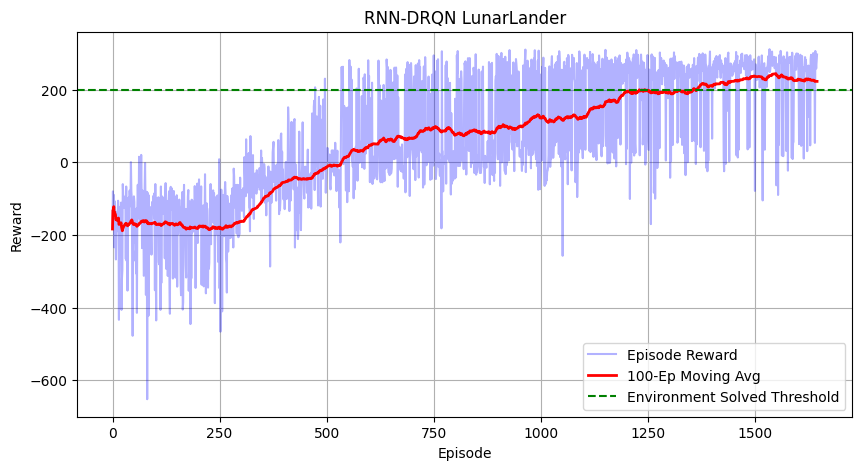

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.3, color="blue", label="Episode Reward")
plt.plot(moving_avg_rewards, color="red", linewidth=2, label="100-Ep Moving Avg")
plt.axhline(y=200, color="green", linestyle="--", label="Environment Solved Threshold")
plt.title("RNN-DRQN LunarLander")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.savefig("rnn_drqn_lunar_lander_progress.png")
plt.show()

In [16]:
# Save the trained model weights
torch.save(policy_net.state_dict(), "rnn_dqn_lunar_lander.pth")
print("Model saved to rnn_dqn_lunar_lander.pth")

Model saved to rnn_dqn_lunar_lander.pth


In [18]:
policy_net = DRQNNetwork().to(device)
policy_net.load_state_dict(torch.load("rnn_dqn_lunar_lander.pth", map_location=device))
policy_net.eval()  # Set network to evaluation mode (turns off dropout, batchnorm etc.)

env = gym.make("LunarLander-v3", continuous=False, render_mode="human")

# Run for 5 demonstration episodes
NUM_EPISODES = 5

for episode in range(NUM_EPISODES):
    observation, info = env.reset()
    episode_reward = 0
    done = False
    
    # Reset the recurrent hidden state at the start of every episode
    hidden_state = None

    print(f"Starting Evaluation Episode {episode + 1}...")

    while not done:
        # Convert observation to tensor and reshape to (batch=1, seq_len=1, features=8)
        state_tensor = torch.FloatTensor(observation).unsqueeze(0).unsqueeze(0).to(device)

        # Always Exploit: Pass both the state and the hidden_state into the network
        with torch.no_grad():
            q_values, hidden_state = policy_net(state_tensor, hidden_state)
            action = torch.argmax(q_values).item()

        # Step the environment
        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        episode_reward += reward

        # Small sleep delay so the human eye can track the landing frame rate
        # time.sleep(0.1)

    print(f"Episode {episode + 1} Finished! Total Reward: {episode_reward:.1f}\n")

env.close()
print("Evaluation Complete!")

Starting Evaluation Episode 1...
Episode 1 Finished! Total Reward: 161.2

Starting Evaluation Episode 2...
Episode 2 Finished! Total Reward: 255.4

Starting Evaluation Episode 3...
Episode 3 Finished! Total Reward: 38.9

Starting Evaluation Episode 4...
Episode 4 Finished! Total Reward: 269.4

Starting Evaluation Episode 5...
Episode 5 Finished! Total Reward: 134.6

Evaluation Complete!


In [17]:
# --- 1. CONFIGURATION ---
NUM_EPISODES = 100      # Number of evaluation runs to aggregate
ALIGN_STEPS = 100       # Standardized time grid (0% to 100% of episode lifetime)
N_COMP = 3              # MACRO: Number of Principal Components to extract and plot

policy_net = DRQNNetwork().to(device)
policy_net.load_state_dict(torch.load("rnn_dqn_lunar_lander.pth", map_location=device))
policy_net.eval() 

env = gym.make("LunarLander-v3", continuous=False, render_mode=None)

all_episodes_raw = []
all_deltas_raw = []

print(f"Gathering data across {NUM_EPISODES} episodes...", flush=True)

# --- 2. DATA GATHERING ---
for ep in range(NUM_EPISODES):
    observation, info = env.reset()
    done = False
    hidden_state = None
    ep_hiddens = []
    
    while not done:
        state_tensor = torch.FloatTensor(observation).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values, next_hidden_state = policy_net(state_tensor, hidden_state)
            action = torch.argmax(q_values).item()

        h_numpy = next_hidden_state.cpu().numpy().flatten()
        ep_hiddens.append(h_numpy)

        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        hidden_state = next_hidden_state
        
    ep_hiddens = np.array(ep_hiddens)
    all_episodes_raw.append(ep_hiddens)
    
    # Compute raw delta for this episode
    ep_delta = np.linalg.norm(ep_hiddens[1:] - ep_hiddens[:-1], axis=1)
    all_deltas_raw.append(ep_delta)

env.close()

Gathering data across 100 episodes...


In [ ]:
# --- 3. TIME-ALIGNMENT VIA INTERPOLATION ---
standardized_hiddens = []
standardized_deltas = []

for ep_matrix in all_episodes_raw:
    old_indices = np.linspace(0, 1, len(ep_matrix))
    new_indices = np.linspace(0, 1, ALIGN_STEPS)
    
    interp_matrix = np.zeros((ALIGN_STEPS, LATENT_DIM))
    for dim in range(LATENT_DIM):
        interp_matrix[:, dim] = np.interp(new_indices, old_indices, ep_matrix[:, dim])
    standardized_hiddens.append(interp_matrix)

for ep_delta in all_deltas_raw:
    old_indices = np.linspace(0, 1, len(ep_delta))
    new_indices = np.linspace(0, 1, ALIGN_STEPS)
    interp_delta = np.interp(new_indices, old_indices, ep_delta)
    standardized_deltas.append(interp_delta)

standardized_hiddens = np.array(standardized_hiddens)
standardized_deltas = np.array(standardized_deltas)

# --- 4. DIMENSIONALITY REDUCTION (GLOBAL SVD WITH N_COMP MACRO) ---
flattened_hiddens = standardized_hiddens.reshape(-1, LATENT_DIM)
mean_vector = np.mean(flattened_hiddens, axis=0)
centered_flattened = flattened_hiddens - mean_vector

U, S, Vt = np.linalg.svd(centered_flattened, full_matrices=False)
# Slice projection matrix using our N_COMP macro value
projection_matrix = Vt[:N_COMP].T

# Project the 3D block into N_COMP space: (NUM_EPISODES, ALIGN_STEPS, N_COMP)
projected_episodes = np.zeros((NUM_EPISODES, ALIGN_STEPS, N_COMP))
for i in range(NUM_EPISODES):
    centered_ep = standardized_hiddens[i] - mean_vector
    projected_episodes[i] = centered_ep @ projection_matrix

# --- 5. COMPUTE STATISTICAL MEAN & STD ---
mean_trajectory = np.mean(projected_episodes, axis=0)  # (ALIGN_STEPS, N_COMP)
std_trajectory = np.std(projected_episodes, axis=0)   # (ALIGN_STEPS, N_COMP)

mean_delta = np.mean(standardized_deltas, axis=0)
std_delta = np.std(standardized_deltas, axis=0)

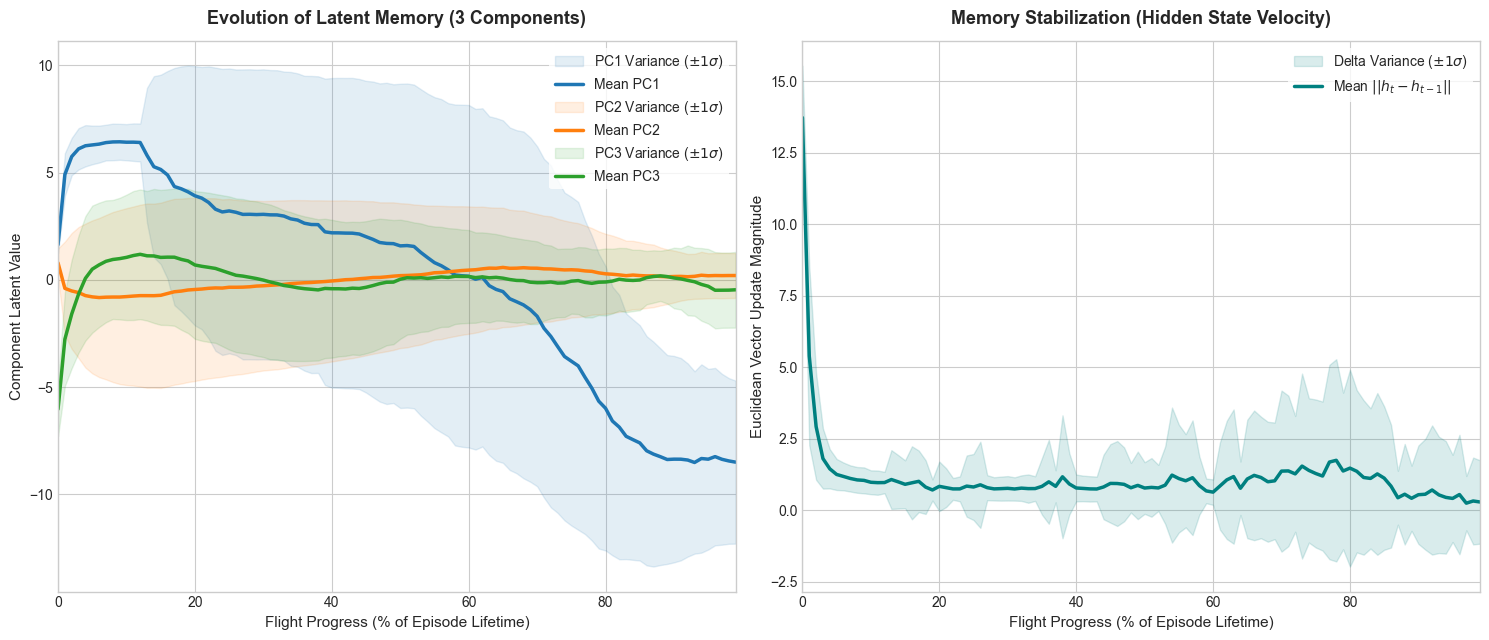

In [19]:
# --- 6. PLOTTING ---
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), dpi=100)

time_grid = np.arange(ALIGN_STEPS)

# Automatically generate distinct colors matching our N_COMP macro limit
cmap = plt.get_cmap('tab10')

# Plot A: Dynamic rendering of N_COMP lines and clouds
for i in range(N_COMP):
    color = cmap(i)
    
    # Shaded variance envelope around Principal Component i
    ax1.fill_between(time_grid, 
                     mean_trajectory[:, i] - std_trajectory[:, i], 
                     mean_trajectory[:, i] + std_trajectory[:, i], 
                     color=color, alpha=0.12, label=f'PC{i+1} Variance ($\pm 1\sigma$)')
    
    # Bold mean lines tracking progression
    ax1.plot(time_grid, mean_trajectory[:, i], color=color, lw=2.5, label=f'Mean PC{i+1}')

ax1.set_title(f"Evolution of Latent Memory ({N_COMP} Components)", fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel("Flight Progress (% of Episode Lifetime)", fontsize=11)
ax1.set_ylabel("Component Latent Value", fontsize=11)
ax1.set_xlim(0, ALIGN_STEPS - 1)
ax1.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

# Plot B: Distance Delta Convergence with Shaded Variance
ax2.fill_between(time_grid, 
                 mean_delta - std_delta, 
                 mean_delta + std_delta, 
                 color='teal', alpha=0.15, label='Delta Variance ($\pm 1\sigma$)')
ax2.plot(time_grid, mean_delta, color='teal', lw=2.5, label='Mean $||h_t - h_{t-1}||$')

ax2.set_title("Memory Stabilization (Hidden State Velocity)", fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel("Flight Progress (% of Episode Lifetime)", fontsize=11)
ax2.set_ylabel("Euclidean Vector Update Magnitude", fontsize=11)
ax2.set_xlim(0, ALIGN_STEPS - 1)
ax2.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

# Code for stability analysis
### 10 Runs of DRQN with different random seeds

In [10]:
import os
N_RUNS = 10
TOTAL_TIMESTEPS = 600000

# Directory to save checkpoint data
SAVE_DIR = "./DRQN_stability_analysis"
os.makedirs(SAVE_DIR, exist_ok=True)

all_runs_logs = []          # Will hold the logged rewards for each run
all_runs_lengths_logs = []  # Will hold the logged final episode count for each run

print(f"Starting Stability Analysis for {N_RUNS} runs...", flush=True)

for run in range(N_RUNS):
    print(f"\n--- Starting Run {run + 1}/{N_RUNS} ---")
    
    # File paths for saving this specific run's data
    reward_file = os.path.join(SAVE_DIR, f"run_{run+1}_rewards.npy")
    length_file = os.path.join(SAVE_DIR, f"run_{run+1}_episodes_count.npy")
    
    # --- INTERRUPTION PROTECTION: CHECK FOR EXISTING DATA ---
    if os.path.exists(reward_file) and os.path.exists(length_file):
        print(f"-> Found existing data for Run {run + 1}. Loading and skipping...")
        run_history = np.load(reward_file).tolist()
        run_lengths_history = np.load(length_file).item() # Loaded as a single value item
        all_runs_logs.append(run_history)
        all_runs_lengths_logs.append(run_lengths_history)
        continue  # Skip to the next run
    
    # 1. RESET / RE-INITIALIZE AGENT & ENVIRONMENT FOR EACH RUN
    env = gym.make("LunarLander-v3", continuous=False)
    
    # Generate a new seed per run for true variance analysis
    run_seed = 42 + run 
    observation, info = env.reset(seed=run_seed)
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    
    # Re-initialize recurrent networks/buffers here:
    policy_net = DRQNNetwork().to(device) # Assumed DRQN network class name
    target_net = DRQNNetwork().to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()  # Target net never calculates gradients

    # Episode-based replay buffer for DRQN
    replay_buffer = deque(maxlen=REPLAY_BUFFER_EPISODES)
    epsilon = EPSILON_START
    hidden_state = None 
    current_episode_transitions = []
    
    # STATISTICS & ADAPTIVE TRACKING
    episode_rewards = []
    current_episode_reward = 0
    current_episode_length = 0
    
    # Optimizer & Loss configuration
    optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.MSELoss()
    
    run_history = []  # Tracks the 100-ep moving average at EVERY step (matching your DQN style)
    
    print(f"Run {run + 1} started. Burn-in: {BURN_IN_LENGTH} steps | Sequence length: {SEQUENCE_LENGTH} steps", flush=True)
    pbar = tqdm(range(TOTAL_TIMESTEPS), desc=f"Run {run + 1} Progress")

    for step in pbar:
        # Formulate recurrent 3D tensor input: (batch_size, sequence_length, features)
        state_tensor = torch.FloatTensor(observation).unsqueeze(0).unsqueeze(0).to(device)

        # Action Selection
        if random.random() < epsilon:
            action = env.action_space.sample()
            with torch.no_grad():
                # Forward pass to update the recurrent hidden state even during exploration
                _, next_hidden_state = policy_net(state_tensor, hidden_state) 
        else:
            with torch.no_grad():
                q_values, next_hidden_state = policy_net(state_tensor, hidden_state)
                action = torch.argmax(q_values).item()

        # Detach and save hidden state for sampling
        if hidden_state is not None:
            saved_hidden = hidden_state.detach().cpu().numpy()
        else:
            saved_hidden = None

        # Step environment
        next_observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        current_episode_reward += reward
        current_episode_length += 1

        # Track transitions sequentially for episodic sampling
        current_episode_transitions.append((observation, action, reward, next_observation, done, saved_hidden, terminated))
        
        observation = next_observation
        hidden_state = next_hidden_state

        # Only train once every TRAIN_FREQ steps using episodic checking
        if len(replay_buffer) >= MIN_REPLAY_EPISODES and step % TRAIN_FREQ == 0:
            train_step() # Assumes internal definitions use local networks or global reference updates

        # Periodically copy weights to the Target Network via Polyak (soft) update
        if len(replay_buffer) >= MIN_REPLAY_EPISODES and step % TARGET_UPDATE_FREQ == 0:
            for target_param, policy_param in zip(target_net.parameters(), policy_net.parameters()):
                target_param.data.copy_(TAU * policy_param.data + (1.0 - TAU) * target_param.data)

        # Step-by-step logging matching DQN (no LOG_FREQ logic)
        avg_reward = np.mean(episode_rewards[-100:]) if episode_rewards else 0.0
        run_history.append(avg_reward)

        # Handle Episode Termination
        if done:
            replay_buffer.append(current_episode_transitions)
            current_episode_transitions = []
            
            episode_rewards.append(current_episode_reward)
            avg_reward = np.mean(episode_rewards[-100:]) if episode_rewards else 0.0

            epsilon = update_epsilon_decay(epsilon)

            pbar.set_postfix({
                "Ep": len(episode_rewards),
                "Steps": f"{current_episode_length}",
                "Last_R": f"{current_episode_reward:.1f}",
                "100-Ep_Avg": f"{avg_reward:.1f}",
                "Epsilon": f"{epsilon:.3f}"
            })

            # Prepare for next episode within this run
            hidden_state = None  # CRITICAL: Reset hidden states for DRQN at episode boundary
            observation, info = env.reset()
            current_episode_reward = 0
            current_episode_length = 0

    # The final total count of completed episodes for this entire run
    final_episode_count = len(episode_rewards)
    env.close()
    
    # --- SAVE TO NUMPY ARRAYS AFTER EACH RUN ---
    np.save(reward_file, np.array(run_history))
    np.save(length_file, np.array(final_episode_count)) # Saves just the single scalar integer
    print(f"-> Saved data for Run {run + 1} to {SAVE_DIR}")
    
    all_runs_logs.append(run_history)
    all_runs_lengths_logs.append(final_episode_count)

print("\nAll training runs finished or loaded! Generating stability plot...")

Starting Stability Analysis for 10 runs...

--- Starting Run 1/10 ---
Run 1 started. Burn-in: 6 steps | Sequence length: 92 steps


Run 1 Progress: 100%|████████████████████| 600000/600000 [1:25:05<00:00, 117.52it/s, Ep=2163, Steps=375, Last_R=272.0, 100-Ep_Avg=247.8, Epsilon=0.010]


-> Saved data for Run 1 to ./DRQN_stability_analysis

--- Starting Run 2/10 ---
Run 2 started. Burn-in: 6 steps | Sequence length: 92 steps


Run 2 Progress: 100%|████████████████████| 600000/600000 [1:22:16<00:00, 121.56it/s, Ep=2574, Steps=311, Last_R=236.4, 100-Ep_Avg=227.2, Epsilon=0.010]


-> Saved data for Run 2 to ./DRQN_stability_analysis

--- Starting Run 3/10 ---
Run 3 started. Burn-in: 6 steps | Sequence length: 92 steps


...

-> Saved data for Run 8 to ./DRQN_stability_analysis

--- Starting Run 9/10 ---
Run 9 started. Burn-in: 6 steps | Sequence length: 92 steps



Run 9 Progress: 100%|████████████████████| 600000/600000 [1:27:50<00:00, 113.84it/s, Ep=2460, Steps=200, Last_R=278.0, 100-Ep_Avg=259.9, Epsilon=0.010]

-> Saved data for Run 9 to ./DRQN_stability_analysis

--- Starting Run 10/10 ---
Run 10 started. Burn-in: 6 steps | Sequence length: 92 steps



Run 10 Progress: 100%|███████████████████| 600000/600000 [1:29:25<00:00, 111.83it/s, Ep=2204, Steps=246, Last_R=251.7, 100-Ep_Avg=140.8, Epsilon=0.010]

-> Saved data for Run 10 to ./DRQN_stability_analysis

All training runs finished or loaded! Generating stability plot...


Loading Stability Analysis data for 10 runs from './DRQN_stability_analysis'...
-> Successfully loaded Run 1 (Total Episodes: 2163)
-> Successfully loaded Run 2 (Total Episodes: 2574)
-> Successfully loaded Run 3 (Total Episodes: 1982)
-> Successfully loaded Run 4 (Total Episodes: 2238)
-> Successfully loaded Run 5 (Total Episodes: 2090)
-> Successfully loaded Run 6 (Total Episodes: 2313)
-> Successfully loaded Run 7 (Total Episodes: 2334)
-> Successfully loaded Run 8 (Total Episodes: 2465)
-> Successfully loaded Run 9 (Total Episodes: 2460)
-> Successfully loaded Run 10 (Total Episodes: 2204)

All data loaded successfully! Processing metrics and generating stability plot...


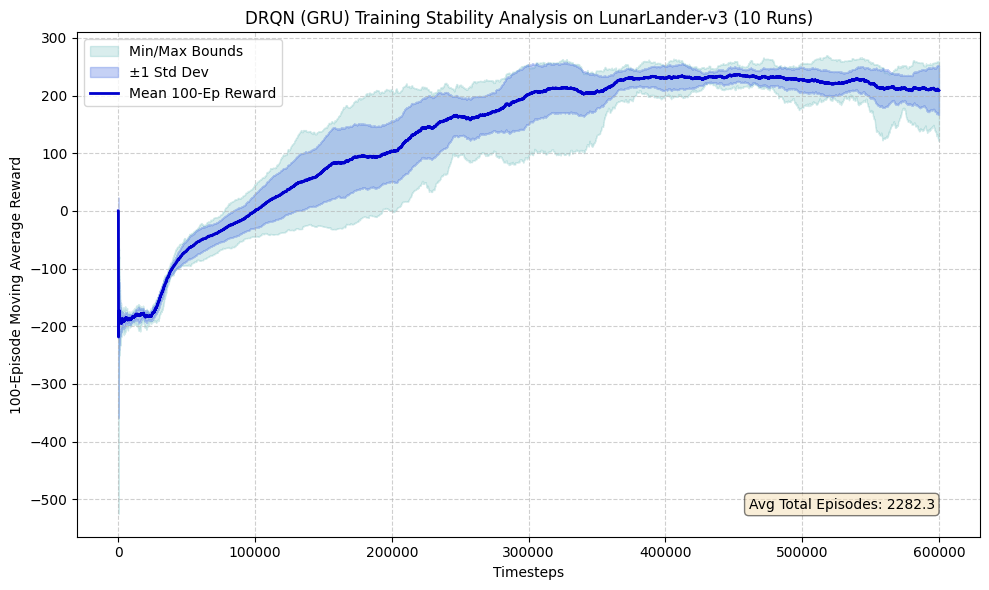

In [11]:
import os
# Configuration
N_RUNS = 10
SAVE_DIR = "./DRQN_stability_analysis"

all_runs_logs = []
all_runs_lengths_logs = []

print(f"Loading Stability Analysis data for {N_RUNS} runs from '{SAVE_DIR}'...")

# --- LOAD DATA FROM SAVED ARRAYS ---
for run in range(N_RUNS):
    reward_file = os.path.join(SAVE_DIR, f"run_{run+1}_rewards.npy")
    length_file = os.path.join(SAVE_DIR, f"run_{run+1}_episodes_count.npy")
    
    if os.path.exists(reward_file) and os.path.exists(length_file):
        # Load the step-by-step reward history
        run_history = np.load(reward_file).tolist()
        # Load the scalar episode count (.item() extracts the scalar from the 0D array)
        run_lengths_history = np.load(length_file).item()
        
        all_runs_logs.append(run_history)
        all_runs_lengths_logs.append(run_lengths_history)
        print(f"-> Successfully loaded Run {run + 1} (Total Episodes: {run_lengths_history})")
    else:
        raise FileNotFoundError(f"Missing data files for Run {run + 1}. Please ensure both {reward_file} and {length_file} exist.")

print("\nAll data loaded successfully! Processing metrics and generating stability plot...")

# --- PROCESS METRICS ---
# Convert to a 2D numpy array: shape (N_RUNS, timesteps_logged)
data_matrix = np.array(all_runs_logs)

# Calculate stats across the runs (axis=0)
mean_trend = np.mean(data_matrix, axis=0)
std_trend = np.std(data_matrix, axis=0)
min_trend = np.min(data_matrix, axis=0)
max_trend = np.max(data_matrix, axis=0)

# Since your training loop saved data at EVERY timestep, your effective LOG_FREQ is 1
effective_log_freq = 1
x_axis = np.arange(len(mean_trend)) * effective_log_freq

# --- PLOTTING ---
plt.figure(figsize=(10, 6))

# 1. Fill the Min/Max total range (Light Cyan shadow)
plt.fill_between(
    x_axis, 
    min_trend, 
    max_trend, 
    color="darkcyan", 
    alpha=0.15, 
    label="Min/Max Bounds"
)

# 2. Fill the Standard Deviation shadow (Royal Blue shadow)
plt.fill_between(
    x_axis, 
    mean_trend - std_trend, 
    mean_trend + std_trend, 
    color="royalblue", 
    alpha=0.3, 
    label="±1 Std Dev"
)

# 3. Plot the mean line (Deep Blue line)
plt.plot(x_axis, mean_trend, label="Mean 100-Ep Reward", color="mediumblue", lw=2)

# Graph embellishments
plt.title(f"DRQN (GRU) Training Stability Analysis on LunarLander-v3 ({N_RUNS} Runs)")
plt.xlabel("Timesteps")
plt.ylabel("100-Episode Moving Average Reward")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)

# Display total average episodes completed across all runs as text on the plot
avg_final_episodes = np.mean(all_runs_lengths_logs)
plt.text(0.95, 0.05, f"Avg Total Episodes: {avg_final_episodes:.1f}", 
         transform=plt.gca().transAxes, ha="right", va="bottom",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()